<a href="https://colab.research.google.com/github/brugerard/Test/blob/Predoc2026/Phos4AfricaGantt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

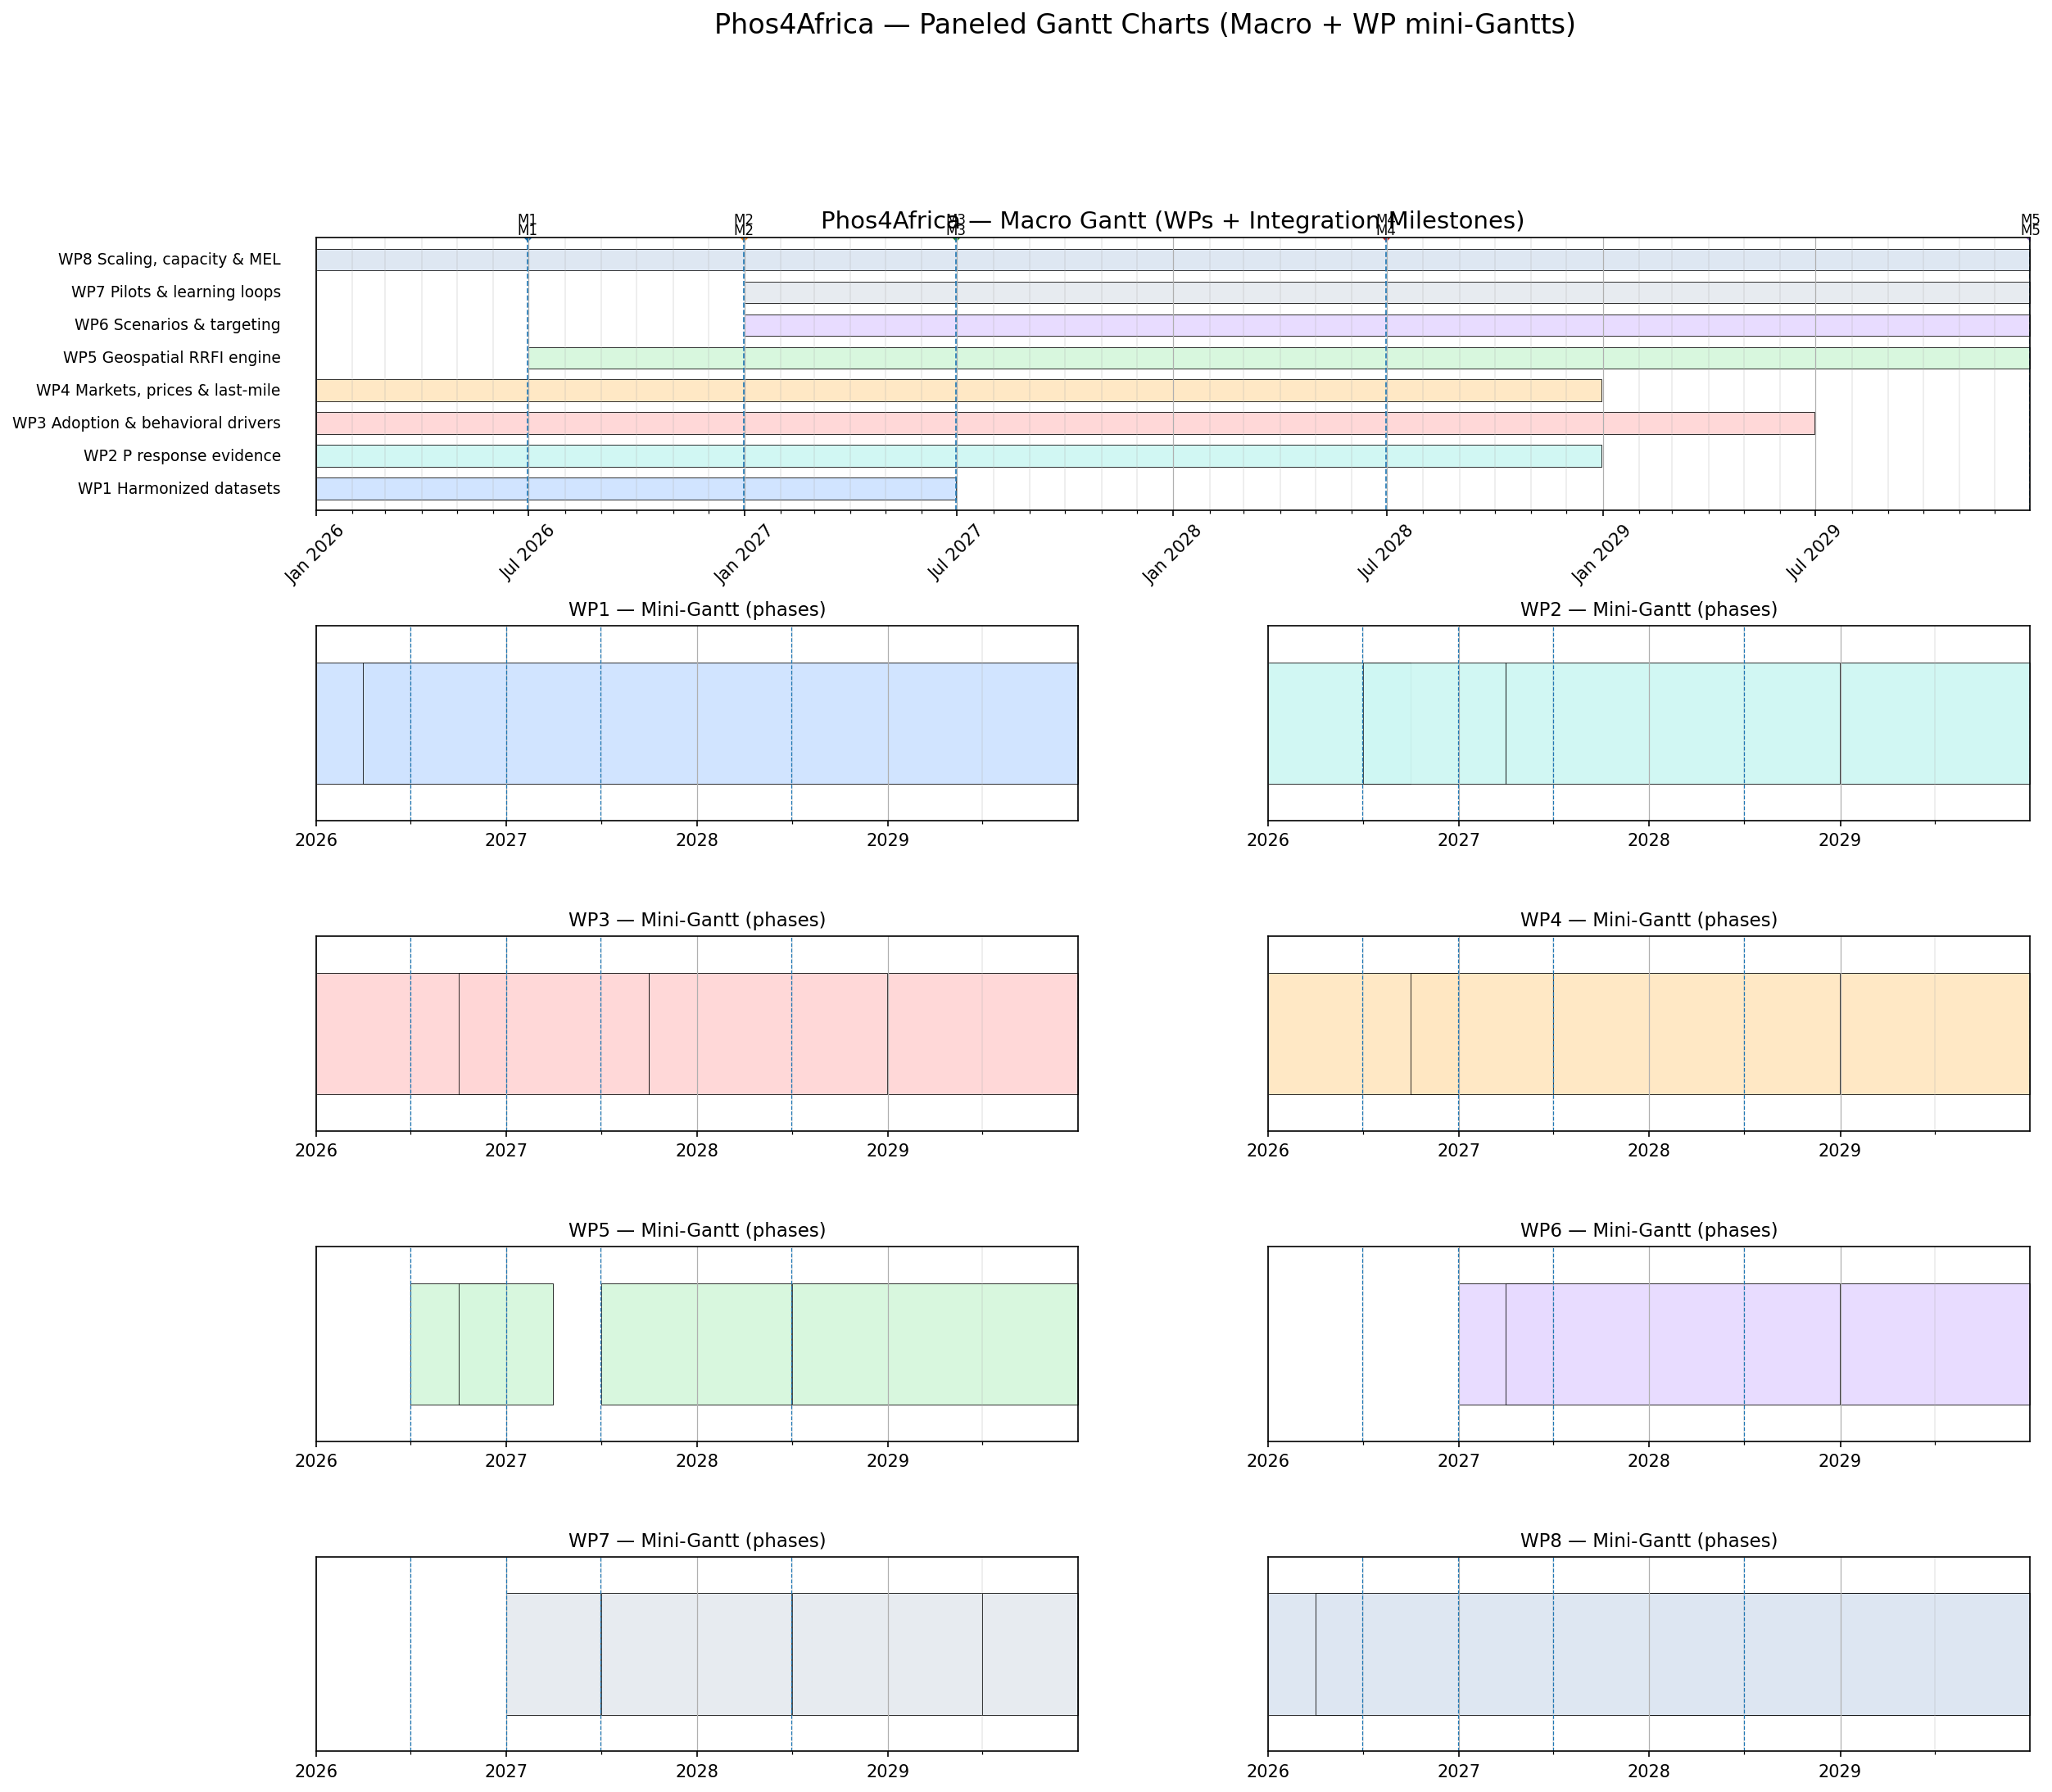

Saved: Phos4Africa_Gantt_Paneled.png


In [ ]:
# ============================================
# Phos4Africa — Gantt charts in Google Colab
# - Macro Gantt (WPs + Milestones M1–M5)
# - Mini-Gantts per WP (3–5 phases each)
# - Paneled figure (Macro on top + 8 mini-panels)
# ============================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from datetime import datetime

# ----------------------------
# 1) Helper functions
# ----------------------------
def d(s: str) -> datetime:
    """Parse date string 'YYYY-MM-DD'."""
    return datetime.strptime(s, "%Y-%m-%d")

def to_num(dt: datetime) -> float:
    """Convert datetime to Matplotlib date number."""
    return mdates.date2num(dt)

def duration_days(start: datetime, end: datetime) -> float:
    """Duration in Matplotlib date units (days)."""
    return to_num(end) - to_num(start)

def setup_time_axis(ax, start_date, end_date, major="6M", minor="1M"):
    """Configure date axis with sensible ticks."""
    ax.set_xlim(to_num(start_date), to_num(end_date))
    ax.xaxis_date()

    # Major ticks
    if major == "6M":
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    elif major == "Q":
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("Q%q %Y"))  # may not work everywhere

    # Minor ticks
    if minor == "1M":
        ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))

    ax.grid(True, axis="x", which="major", linewidth=0.6)
    ax.grid(True, axis="x", which="minor", linewidth=0.2)
    ax.tick_params(axis="x", labelrotation=45)

def add_milestones(ax, milestones, y, label_offset=2):
    """Add milestone diamonds + labels at a given y."""
    for name, dt in milestones.items():
        x = to_num(dt)
        ax.scatter([x], [y], marker="D", s=40)
        ax.text(x, y + label_offset, name, fontsize=8, ha="center", va="bottom")

def draw_gantt_rows(ax, rows, start_date, end_date, row_height=8, row_gap=3,
                    show_labels=True, bar_alpha=0.95):
    """
    rows: list of dicts:
      {
        "label": "WP1 ...",
        "color": "#RRGGBB",
        "tasks": [("Phase name", start_dt, end_dt), ...]
      }
    """
    setup_time_axis(ax, start_date, end_date)

    y_positions = []
    y = 0
    for row in rows:
        y_positions.append(y)
        # Draw each task as a bar in the same row
        for (tname, s, e) in row["tasks"]:
            ax.broken_barh(
                [(to_num(s), duration_days(s, e))],
                (y, row_height),
                facecolors=row.get("color", None),
                alpha=bar_alpha,
                edgecolor="black",
                linewidth=0.4
            )
        # Label the row
        if show_labels:
            ax.text(to_num(start_date) - 30, y + row_height/2, row["label"],
                    ha="right", va="center", fontsize=9)
        y += row_height + row_gap

    ax.set_ylim(-row_gap, y)
    ax.set_yticks([])
    return y_positions


# ----------------------------
# 2) Timeline boundaries
# ----------------------------
START = d("2026-01-01")
END   = d("2029-12-31")

# ----------------------------
# 3) Milestones (edit if needed)
# ----------------------------
milestones = {
    "M1": d("2026-06-30"),  # Data standards & interoperability
    "M2": d("2026-12-31"),  # RRFI v1 (alpha)
    "M3": d("2027-06-30"),  # Targeting + pilot package
    "M4": d("2028-06-30"),  # RRFI v2 validated
    "M5": d("2029-12-31"),  # Scaling toolkit + OSP integration
}

# ----------------------------
# 4) WP colors (edit freely)
# ----------------------------
WP_COLORS = {
    "WP1": "#CFE3FF",
    "WP2": "#CFF7F3",
    "WP3": "#FFD6D6",
    "WP4": "#FFE7C2",
    "WP5": "#D6F7DD",
    "WP6": "#E7DAFF",
    "WP7": "#E6EAF0",
    "WP8": "#DDE6F2",
}

# ----------------------------
# 5) Macro Gantt (WPs only)
# ----------------------------
macro_rows = [
    {"label":"WP1 Harmonized datasets",           "color":WP_COLORS["WP1"], "tasks":[("WP1", d("2026-01-01"), d("2027-06-30"))]},
    {"label":"WP2 P response evidence",           "color":WP_COLORS["WP2"], "tasks":[("WP2", d("2026-01-01"), d("2028-12-31"))]},
    {"label":"WP3 Adoption & behavioral drivers", "color":WP_COLORS["WP3"], "tasks":[("WP3", d("2026-01-01"), d("2029-06-30"))]},
    {"label":"WP4 Markets, prices & last-mile",   "color":WP_COLORS["WP4"], "tasks":[("WP4", d("2026-01-01"), d("2028-12-31"))]},
    {"label":"WP5 Geospatial RRFI engine",        "color":WP_COLORS["WP5"], "tasks":[("WP5", d("2026-07-01"), d("2029-12-31"))]},
    {"label":"WP6 Scenarios & targeting",         "color":WP_COLORS["WP6"], "tasks":[("WP6", d("2027-01-01"), d("2029-12-31"))]},
    {"label":"WP7 Pilots & learning loops",       "color":WP_COLORS["WP7"], "tasks":[("WP7", d("2027-01-01"), d("2029-12-31"))]},
    {"label":"WP8 Scaling, capacity & MEL",       "color":WP_COLORS["WP8"], "tasks":[("WP8", d("2026-01-01"), d("2029-12-31"))]},
]

# ----------------------------
# 6) Mini-Gantts per WP (3–5 phases each)
#    Edit phases/dates to match your final plan.
# ----------------------------
mini = {
    "WP1": [
        ("Standards alignment & data model", d("2026-01-01"), d("2026-06-30")),
        ("Acquisition + harmonization v1",   d("2026-04-01"), d("2026-12-31")),
        ("Updates + maintenance",            d("2027-01-01"), d("2029-12-31")),
    ],
    "WP2": [
        ("Trial inventory + protocol",       d("2026-01-01"), d("2026-09-30")),
        ("Response functions v1",            d("2026-07-01"), d("2027-03-31")),
        ("Refinement + validation",          d("2027-04-01"), d("2028-12-31")),
        ("Packaging for OSP/scale",          d("2029-01-01"), d("2029-12-31")),
    ],
    "WP3": [
        ("Diagnostics + instruments",        d("2026-01-01"), d("2026-12-31")),
        ("Models/priors v1",                 d("2026-10-01"), d("2027-09-30")),
        ("Targeting insights + learning",    d("2027-10-01"), d("2028-12-31")),
        ("Scaling playbooks",                d("2029-01-01"), d("2029-12-31")),
    ],
    "WP4": [
        ("Market/logistics diagnostics",     d("2026-01-01"), d("2026-12-31")),
        ("Affordability layers v1",          d("2026-10-01"), d("2027-06-30")),
        ("Scenario updates + levers",        d("2027-07-01"), d("2028-12-31")),
        ("Supply-chain playbooks",           d("2029-01-01"), d("2029-12-31")),
    ],
    "WP5": [
        ("Architecture + integration build", d("2026-07-01"), d("2026-12-31")),
        ("RRFI v1 build/test",               d("2026-10-01"), d("2027-03-31")),
        ("RRFI v2 recalibration",            d("2027-07-01"), d("2028-06-30")),
        ("Operationalization + APIs",         d("2028-07-01"), d("2029-12-31")),
    ],
    "WP6": [
        ("Scenario framework",               d("2027-01-01"), d("2027-06-30")),
        ("Targeting/bundling v1",            d("2027-04-01"), d("2027-12-31")),
        ("Optimization + scenarios",          d("2028-01-01"), d("2028-12-31")),
        ("Refresh for scale",                d("2029-01-01"), d("2029-12-31")),
    ],
    "WP7": [
        ("Co-design + site selection",       d("2027-01-01"), d("2027-06-30")),
        ("Pilot cycle 1 + monitoring",       d("2027-07-01"), d("2028-06-30")),
        ("Pilot cycle 2 + validation",       d("2028-07-01"), d("2029-06-30")),
        ("Synthesis + validated packages",   d("2029-07-01"), d("2029-12-31")),
    ],
    "WP8": [
        ("MEL design + baseline",            d("2026-01-01"), d("2026-06-30")),
        ("Capacity + comms (continuous)",    d("2026-04-01"), d("2029-12-31")),
        ("Scaling toolkit + OSP cycles",     d("2028-01-01"), d("2029-12-31")),
    ],
}

# ----------------------------
# 7) Build paneled figure
#    Macro on top; mini-panels below (4x2 grid)
# ----------------------------
fig = plt.figure(figsize=(18, 16), dpi=150)
gs = GridSpec(nrows=5, ncols=2, figure=fig, height_ratios=[1.4, 1, 1, 1, 1], hspace=0.55, wspace=0.25)

# --- Macro Gantt (spans both columns)
ax_macro = fig.add_subplot(gs[0, :])
ypos = draw_gantt_rows(ax_macro, macro_rows, START, END, row_height=8, row_gap=4, show_labels=True)
ax_macro.set_title("Phos4Africa — Macro Gantt (WPs + Integration Milestones)", fontsize=14)

# Milestones on macro (place above first row)
add_milestones(ax_macro, milestones, y=ypos[-1] + 14, label_offset=2)

# Add vertical milestone lines (optional but helpful)
for mname, mdt in milestones.items():
    ax_macro.axvline(to_num(mdt), linewidth=0.8, linestyle="--")
    ax_macro.text(to_num(mdt), ax_macro.get_ylim()[1], mname, fontsize=8, ha="center", va="bottom")

# --- Mini-panels order
order = ["WP1", "WP2", "WP3", "WP4", "WP5", "WP6", "WP7", "WP8"]

for idx, wp in enumerate(order):
    r = 1 + idx // 2
    c = idx % 2
    ax = fig.add_subplot(gs[r, c])

    rows = [{
        "label": wp,
        "color": WP_COLORS[wp],
        "tasks": mini[wp],
    }]

    draw_gantt_rows(ax, rows, START, END, row_height=10, row_gap=3, show_labels=False)

    # Milestone lines on mini-panels
    for mname, mdt in milestones.items():
        ax.axvline(to_num(mdt), linewidth=0.6, linestyle="--")

    ax.set_title(f"{wp} — Mini-Gantt (phases)", fontsize=11)

    # Show fewer x labels on mini-panels
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1,7]))
    ax.grid(True, axis="x", which="major", linewidth=0.6)
    ax.grid(True, axis="x", which="minor", linewidth=0.2)
    ax.tick_params(axis="x", labelrotation=0)

fig.suptitle("Phos4Africa — Paneled Gantt Charts (Macro + WP mini-Gantts)", fontsize=16, y=0.995)

# ----------------------------
# 8) Save high-res output for Word
# ----------------------------
out_png = "Phos4Africa_Gantt_Paneled.png"
plt.savefig(out_png, bbox_inches="tight")
plt.show()

print(f"Saved: {out_png}")


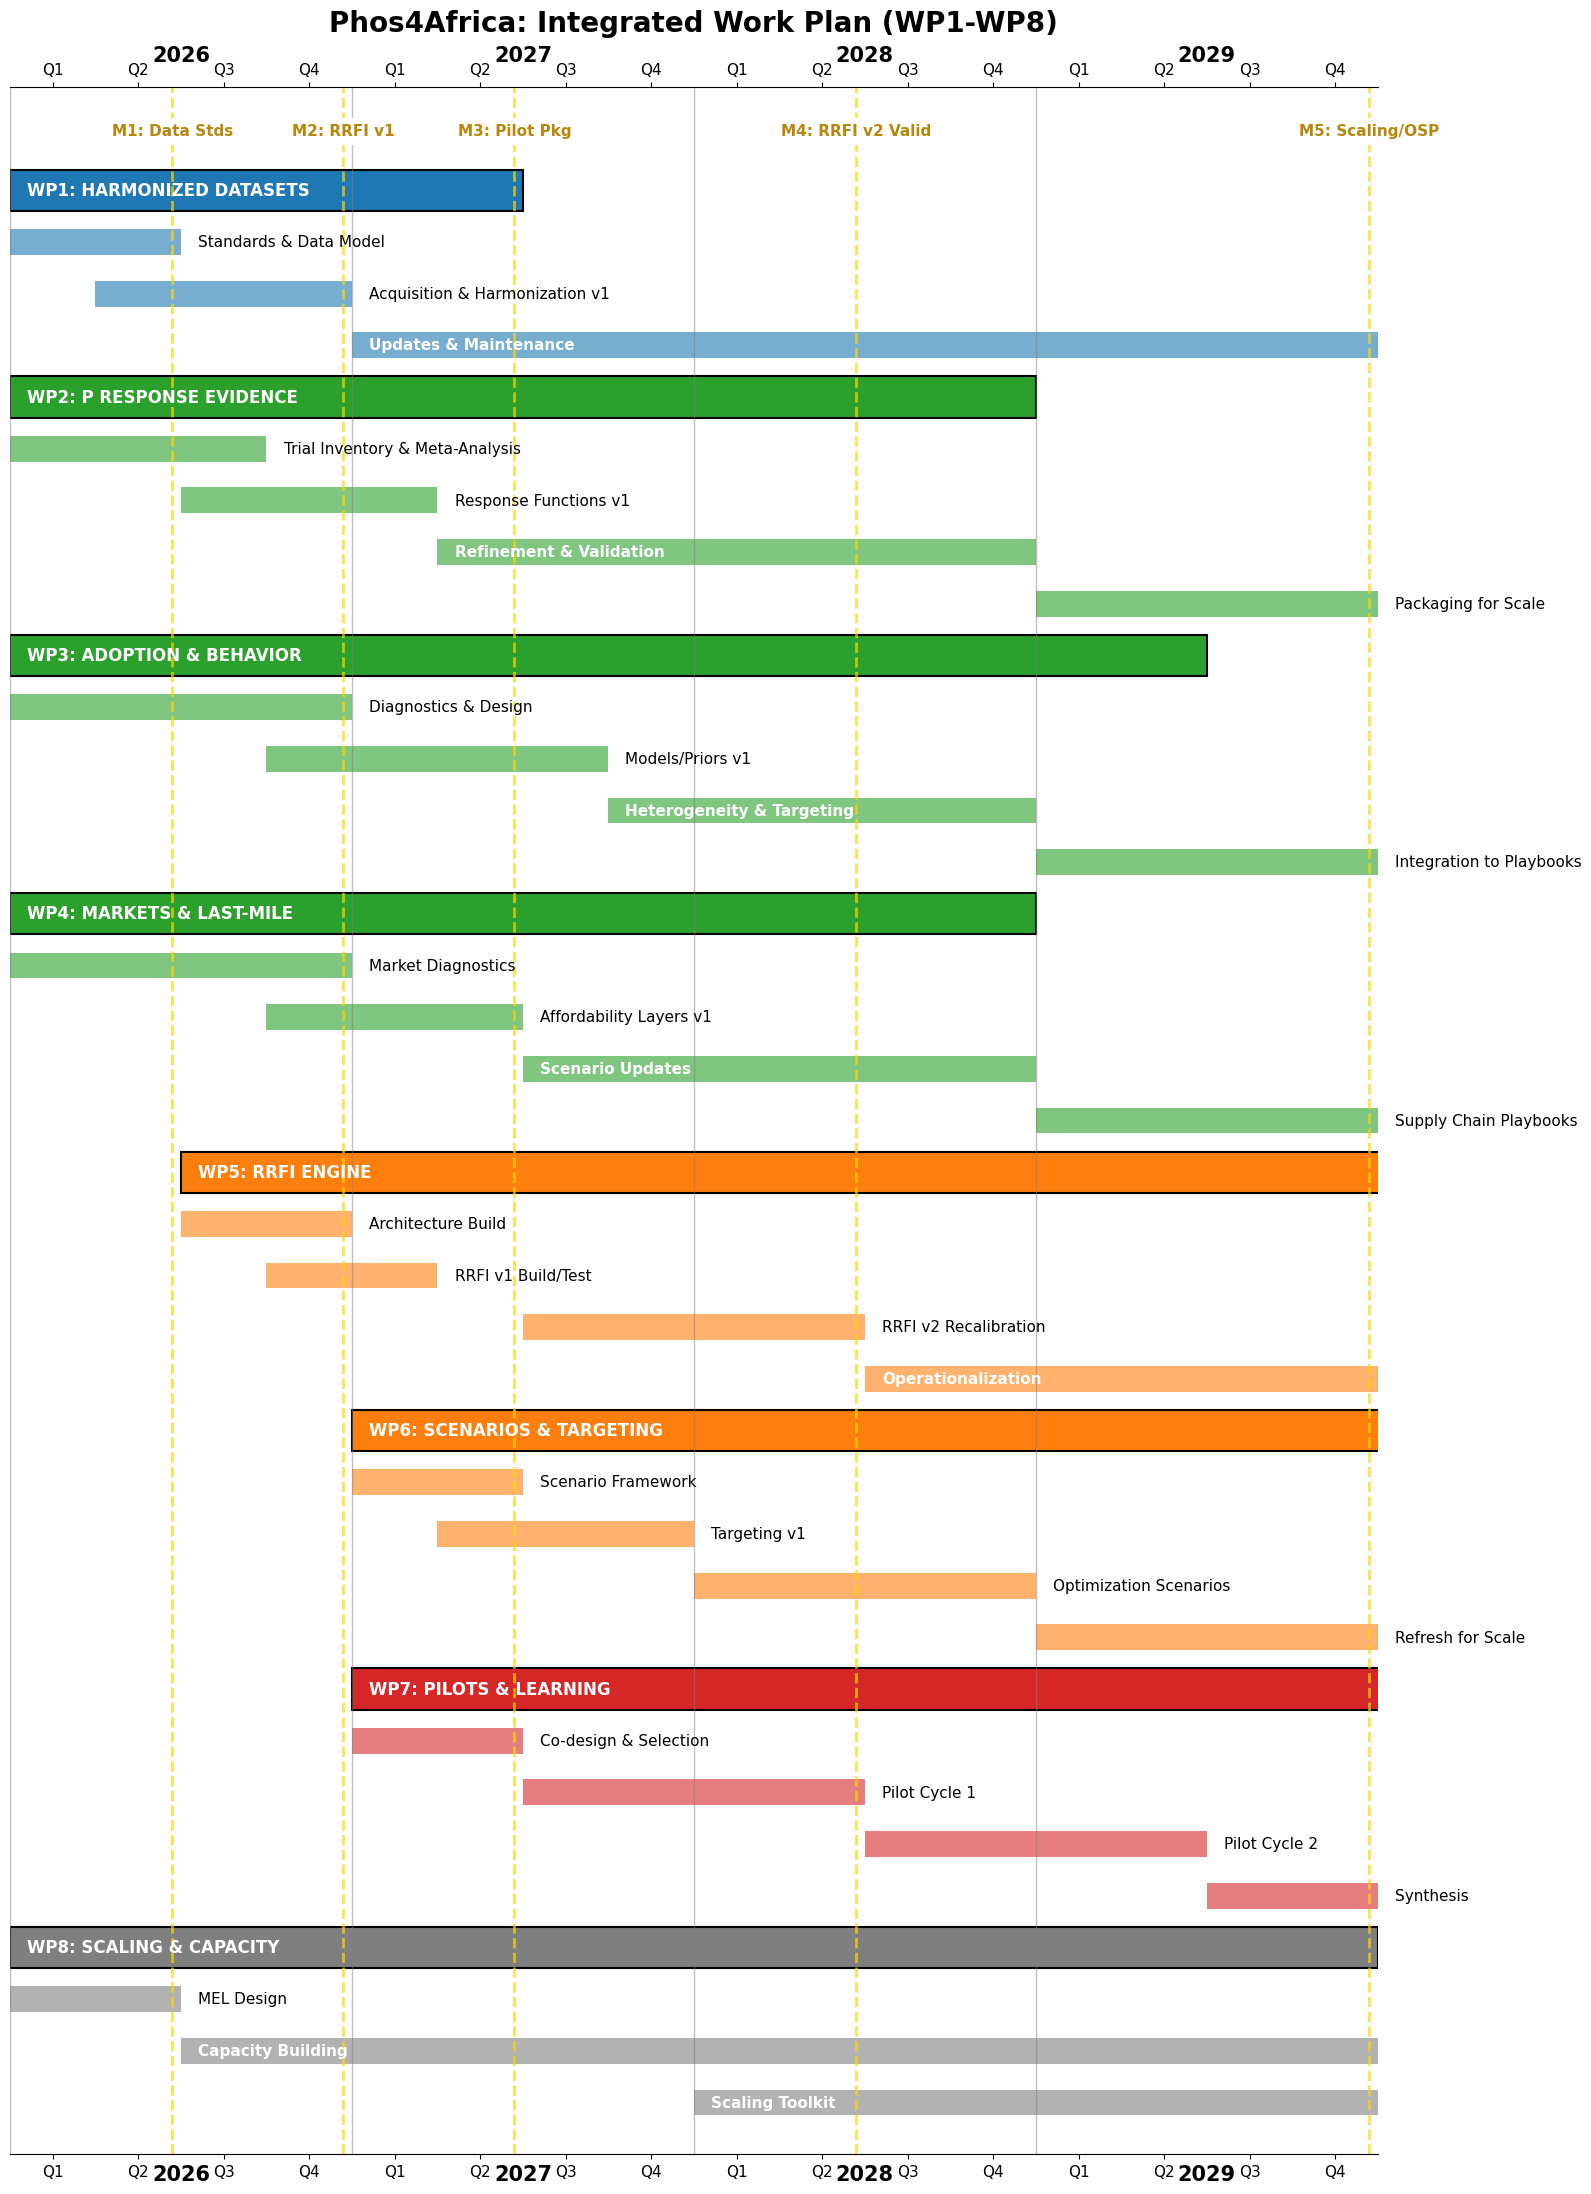

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def create_unified_gantt_chart():
    # Setup the timeline (16 quarters from Q1 2026 to Q4 2029)
    quarters = 16
    years = [2026, 2027, 2028, 2029]
    q_labels = ["Q1", "Q2", "Q3", "Q4"] * 4

    # Define Colors (Phos4Africa Scheme)
    c_data = '#1f77b4'   # Blue
    c_model = '#2ca02c'  # Green
    c_eng = '#ff7f0e'    # Orange
    c_pilot = '#d62728'  # Red
    c_scale = '#7f7f7f'  # Grey

    # Define Milestones
    milestones = [
        (1.9, "M1: Data Stds"),       # Q2 2026 End
        (3.9, "M2: RRFI v1"),         # Q4 2026 End
        (5.9, "M3: Pilot Pkg"),       # Q2 2027 End
        (9.9, "M4: RRFI v2 Valid"),   # Q2 2028 End
        (15.9, "M5: Scaling/OSP")     # Q4 2029 End
    ]

    # Combined Data Structure
    all_rows = []

    # Helper to add WP
    def add_wp(code, name, macro_start, macro_dur, color, tasks):
        # Add Macro Header
        all_rows.append( (f"{code}: {name}", macro_start, macro_dur, color, 'Macro') )
        # Add Tasks
        for t_name, t_start, t_dur in tasks:
            all_rows.append( (t_name, t_start, t_dur, color, 'Task') )

    # Define Content
    add_wp("WP1", "Harmonized Datasets", 0, 6, c_data, [
        ("Standards & Data Model", 0, 2),
        ("Acquisition & Harmonization v1", 1, 3),
        ("Updates & Maintenance", 4, 12)
    ])
    add_wp("WP2", "P Response Evidence", 0, 12, c_model, [
        ("Trial Inventory & Meta-Analysis", 0, 3),
        ("Response Functions v1", 2, 3),
        ("Refinement & Validation", 5, 7),
        ("Packaging for Scale", 12, 4)
    ])
    add_wp("WP3", "Adoption & Behavior", 0, 14, c_model, [
        ("Diagnostics & Design", 0, 4),
        ("Models/Priors v1", 3, 4),
        ("Heterogeneity & Targeting", 7, 5),
        ("Integration to Playbooks", 12, 4)
    ])
    add_wp("WP4", "Markets & Last-Mile", 0, 12, c_model, [
        ("Market Diagnostics", 0, 4),
        ("Affordability Layers v1", 3, 3),
        ("Scenario Updates", 6, 6),
        ("Supply Chain Playbooks", 12, 4)
    ])
    add_wp("WP5", "RRFI Engine", 2, 16, c_eng, [
        ("Architecture Build", 2, 2),
        ("RRFI v1 Build/Test", 3, 2),
        ("RRFI v2 Recalibration", 6, 4),
        ("Operationalization", 10, 6)
    ])
    add_wp("WP6", "Scenarios & Targeting", 4, 16, c_eng, [
        ("Scenario Framework", 4, 2),
        ("Targeting v1", 5, 3),
        ("Optimization Scenarios", 8, 4),
        ("Refresh for Scale", 12, 4)
    ])
    add_wp("WP7", "Pilots & Learning", 4, 16, c_pilot, [
        ("Co-design & Selection", 4, 2),
        ("Pilot Cycle 1", 6, 4),
        ("Pilot Cycle 2", 10, 4),
        ("Synthesis", 14, 2)
    ])
    add_wp("WP8", "Scaling & Capacity", 0, 16, c_scale, [
        ("MEL Design", 0, 2),
        ("Capacity Building", 2, 14),
        ("Scaling Toolkit", 8, 8)
    ])

    # Reverse for plotting (Top=WP1)
    plot_data = all_rows[::-1]

    # Plotting
    fig, ax = plt.subplots(figsize=(16, 22)) # Tall figure for one panel

    # Iterate and plot
    for i, (label, start, duration, color, r_type) in enumerate(plot_data):
        y = i
        if r_type == 'Macro':
            # Header Bar
            ax.barh(y, duration, left=start, height=0.8, color=color, alpha=1.0, edgecolor='black', linewidth=1.5)
            ax.text(start + 0.2, y, label.upper(), va='center', ha='left', color='white', weight='bold', fontsize=12)
        else:
            # Task Bar
            ax.barh(y, duration, left=start, height=0.5, color=color, alpha=0.6, edgecolor=None)
            if duration > 4:
                ax.text(start + 0.2, y, label, va='center', ha='left', color='white', fontsize=11, weight='bold')
            else:
                ax.text(start + duration + 0.2, y, label, va='center', ha='left', color='black', fontsize=11)

    # Add Vertical Milestone Lines
    for mx, mlabel in milestones:
        ax.axvline(x=mx, color='gold', linestyle='--', linewidth=2, alpha=0.7)
        ax.text(mx, len(plot_data), mlabel, ha='center', va='bottom', fontsize=11, weight='bold', color='#B8860B', backgroundcolor='white')

    # Formatting Axis
    ax.set_ylim(-1, len(plot_data) + 1)
    ax.set_xlim(0, 16)
    ax.set_yticks([]) # Hide y ticks

    # Custom X Axis
    ax.set_xticks(np.arange(16) + 0.5)
    ax.set_xticklabels(q_labels, fontsize=11)
    ax.tick_params(axis='x', which='both', bottom=True, top=True, labelbottom=True, labeltop=True)

    # Year Grid
    for y_idx, year in enumerate(years):
        ax.axvline(x=y_idx*4, color='gray', linestyle='-', linewidth=1, alpha=0.5)
        ax.text(y_idx*4 + 2, -1.5, str(year), ha='center', weight='bold', fontsize=15)
        ax.text(y_idx*4 + 2, len(plot_data) + 1.5, str(year), ha='center', weight='bold', fontsize=15)

    ax.set_title("Phos4Africa: Integrated Work Plan (WP1-WP8)", fontsize=20, weight='bold', pad=40)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    plt.tight_layout()
    plt.savefig('phos4africa_unified_gantt.png', dpi=300)
    plt.show()

create_unified_gantt_chart()

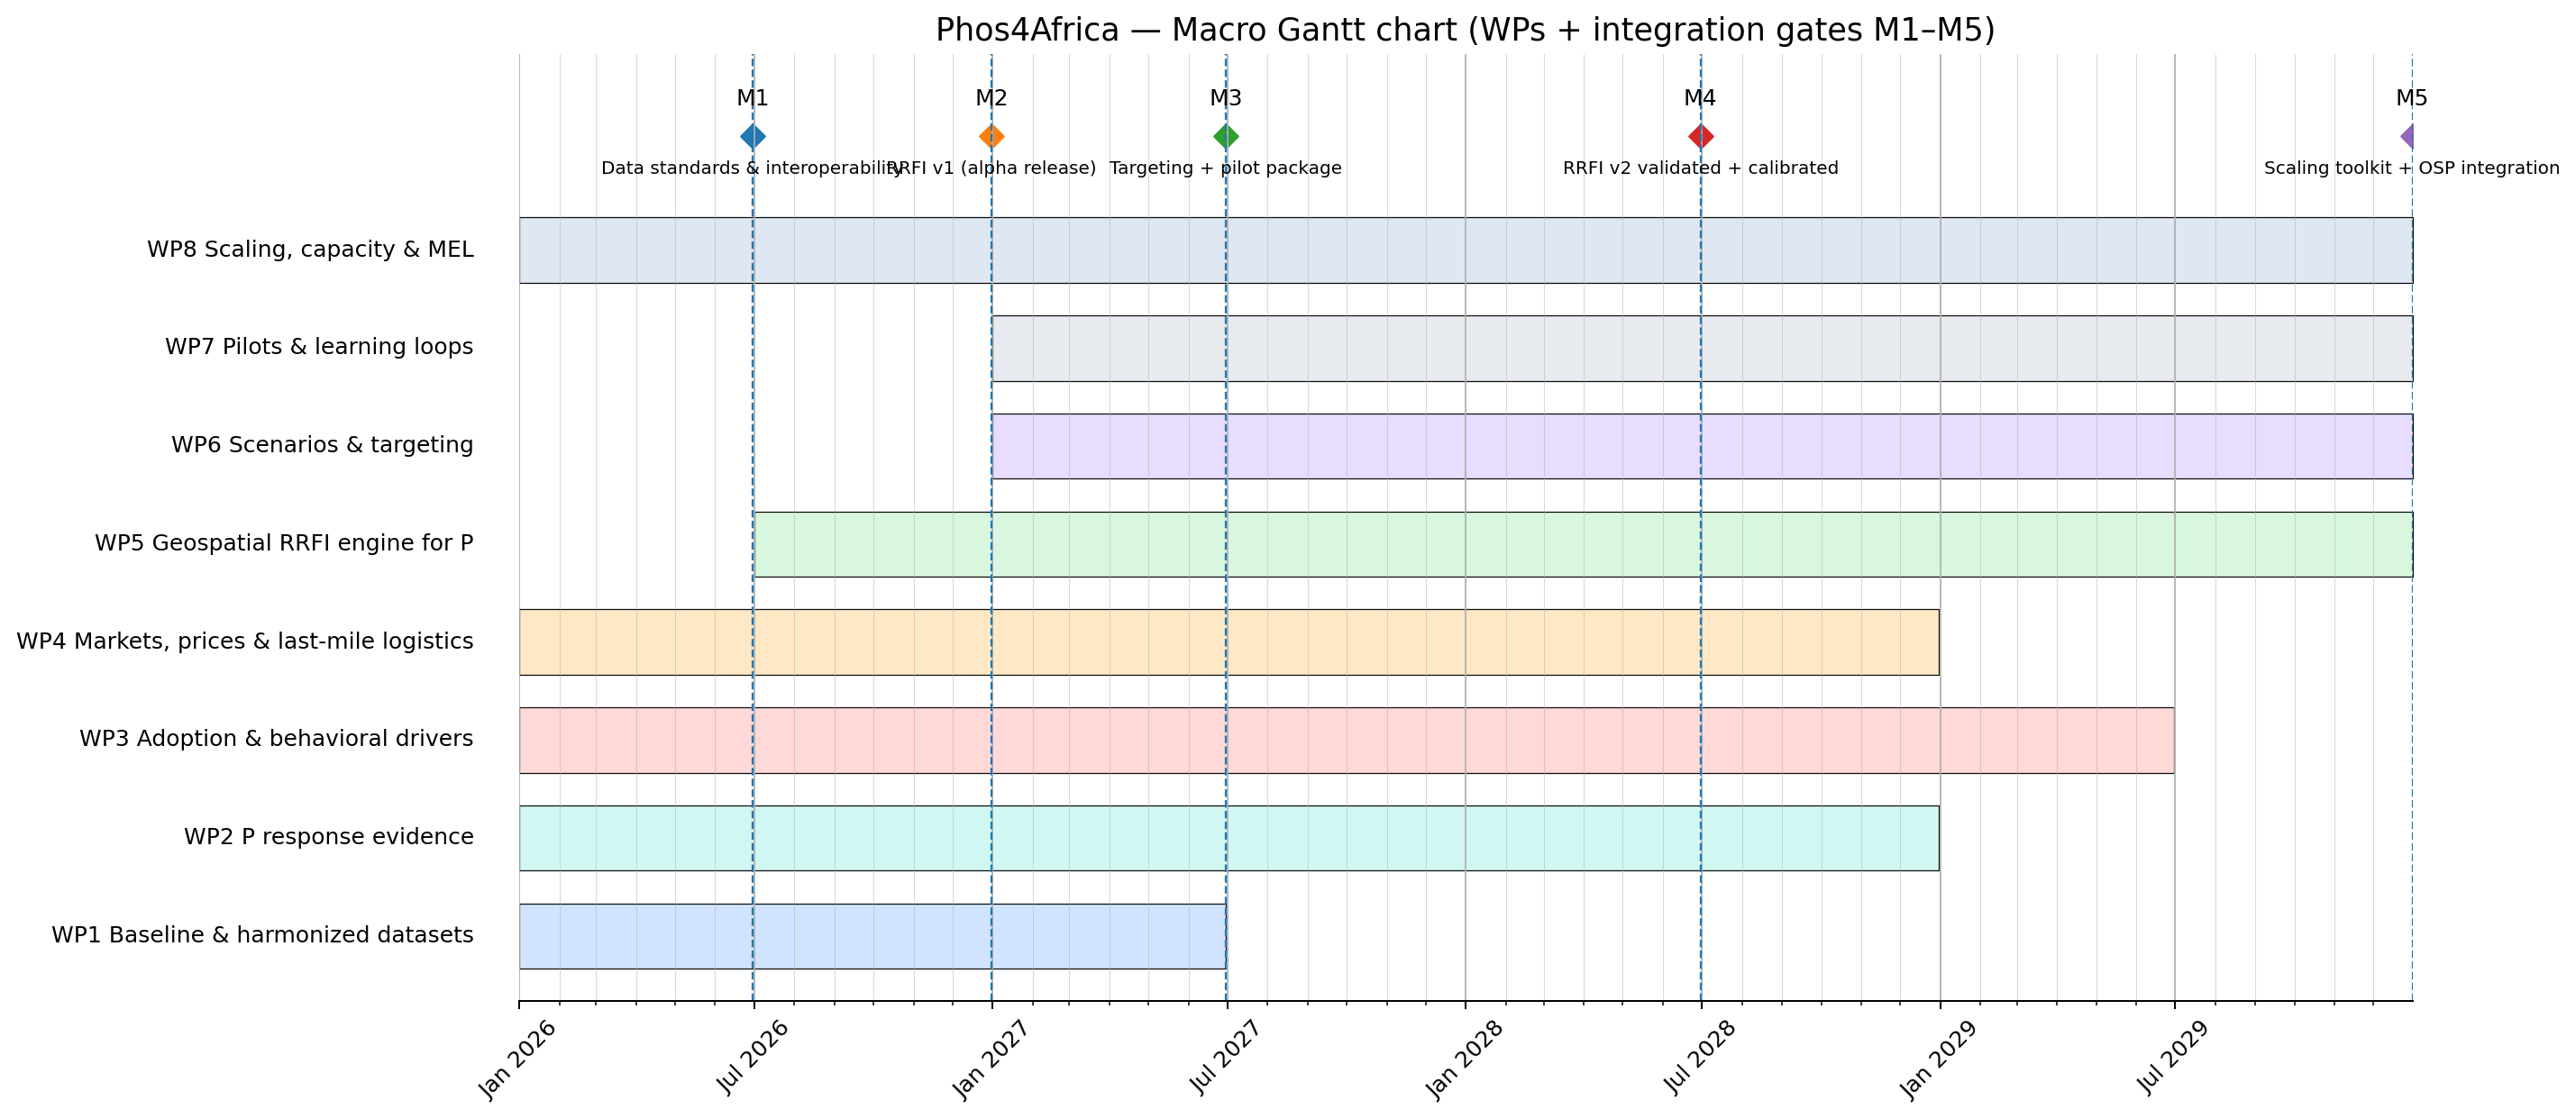

Saved: Phos4Africa_Macro_Gantt.png


In [ ]:
# ============================================================
# Phos4Africa — Improved Overall (Macro) Gantt Chart (Colab)
# - Clean, proposal-ready macro Gantt (WPs only)
# - Integration gates M1–M5 shown as diamonds + vertical lines
# - Exports high-res PNG for Word
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# -----------------------------
# Helpers
# -----------------------------
def d(s: str) -> datetime:
    return datetime.strptime(s, "%Y-%m-%d")

def num(dt: datetime) -> float:
    return mdates.date2num(dt)

def span(s: datetime, e: datetime) -> float:
    return num(e) - num(s)

# -----------------------------
# Timeline (EDIT if needed)
# -----------------------------
START = d("2026-01-01")
END   = d("2029-12-31")

# -----------------------------
# Integration gates (EDIT if needed)
# -----------------------------
GATES = [
    ("M1", d("2026-06-30"), "Data standards & interoperability"),
    ("M2", d("2026-12-31"), "RRFI v1 (alpha release)"),
    ("M3", d("2027-06-30"), "Targeting + pilot package"),
    ("M4", d("2028-06-30"), "RRFI v2 validated + calibrated"),
    ("M5", d("2029-12-31"), "Scaling toolkit + OSP integration"),
]

# -----------------------------
# Work Packages (macro bars)
# (EDIT the start/end dates to match your final plan)
# -----------------------------
WPS = [
    ("WP1 Baseline & harmonized datasets",          d("2026-01-01"), d("2027-06-30")),
    ("WP2 P response evidence",                     d("2026-01-01"), d("2028-12-31")),
    ("WP3 Adoption & behavioral drivers",           d("2026-01-01"), d("2029-06-30")),
    ("WP4 Markets, prices & last-mile logistics",   d("2026-01-01"), d("2028-12-31")),
    ("WP5 Geospatial RRFI engine for P",            d("2026-07-01"), d("2029-12-31")),
    ("WP6 Scenarios & targeting",                   d("2027-01-01"), d("2029-12-31")),
    ("WP7 Pilots & learning loops",                 d("2027-01-01"), d("2029-12-31")),
    ("WP8 Scaling, capacity & MEL",                 d("2026-01-01"), d("2029-12-31")),
]

# Optional: color palette (do not worry about specific colors if you prefer default)
WP_COLORS = [
    "#CFE3FF", "#CFF7F3", "#FFD6D6", "#FFE7C2",
    "#D6F7DD", "#E7DAFF", "#E6EAF0", "#DDE6F2"
]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(16, 7), dpi=180)

row_h = 8
row_gap = 4

# Draw WP bars (top to bottom)
y = 0
for i, (label, s, e) in enumerate(WPS):
    ax.broken_barh([(num(s), span(s, e))], (y, row_h),
                   facecolors=WP_COLORS[i % len(WP_COLORS)],
                   edgecolor="black", linewidth=0.5, alpha=0.95)
    ax.text(num(START) - 35, y + row_h/2, label, ha="right", va="center", fontsize=10)
    y += row_h + row_gap

# Milestone row above the WPs
milestone_y = y + 6

# Add gate markers, labels, and vertical lines
for code, dt, desc in GATES:
    x = num(dt)
    ax.axvline(x, linestyle="--", linewidth=0.9)
    ax.scatter([x], [milestone_y], marker="D", s=55)
    ax.text(x, milestone_y + 3.2, code, ha="center", va="bottom", fontsize=10)
    ax.text(x, milestone_y - 3.0, desc, ha="center", va="top", fontsize=8)

# Axis formatting
ax.set_xlim(num(START), num(END))
ax.set_ylim(-row_gap, milestone_y + 10)
ax.set_yticks([])

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
ax.grid(True, axis="x", which="major", linewidth=0.7)
ax.grid(True, axis="x", which="minor", linewidth=0.2)
ax.tick_params(axis="x", labelrotation=45)

ax.set_title("Phos4Africa — Macro Gantt chart (WPs + integration gates M1–M5)", fontsize=14)

# Clean spines
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()

# -----------------------------
# Export for Word
# -----------------------------
out = "Phos4Africa_Macro_Gantt.png"
plt.savefig(out, bbox_inches="tight")
plt.show()

print(f"Saved: {out}")


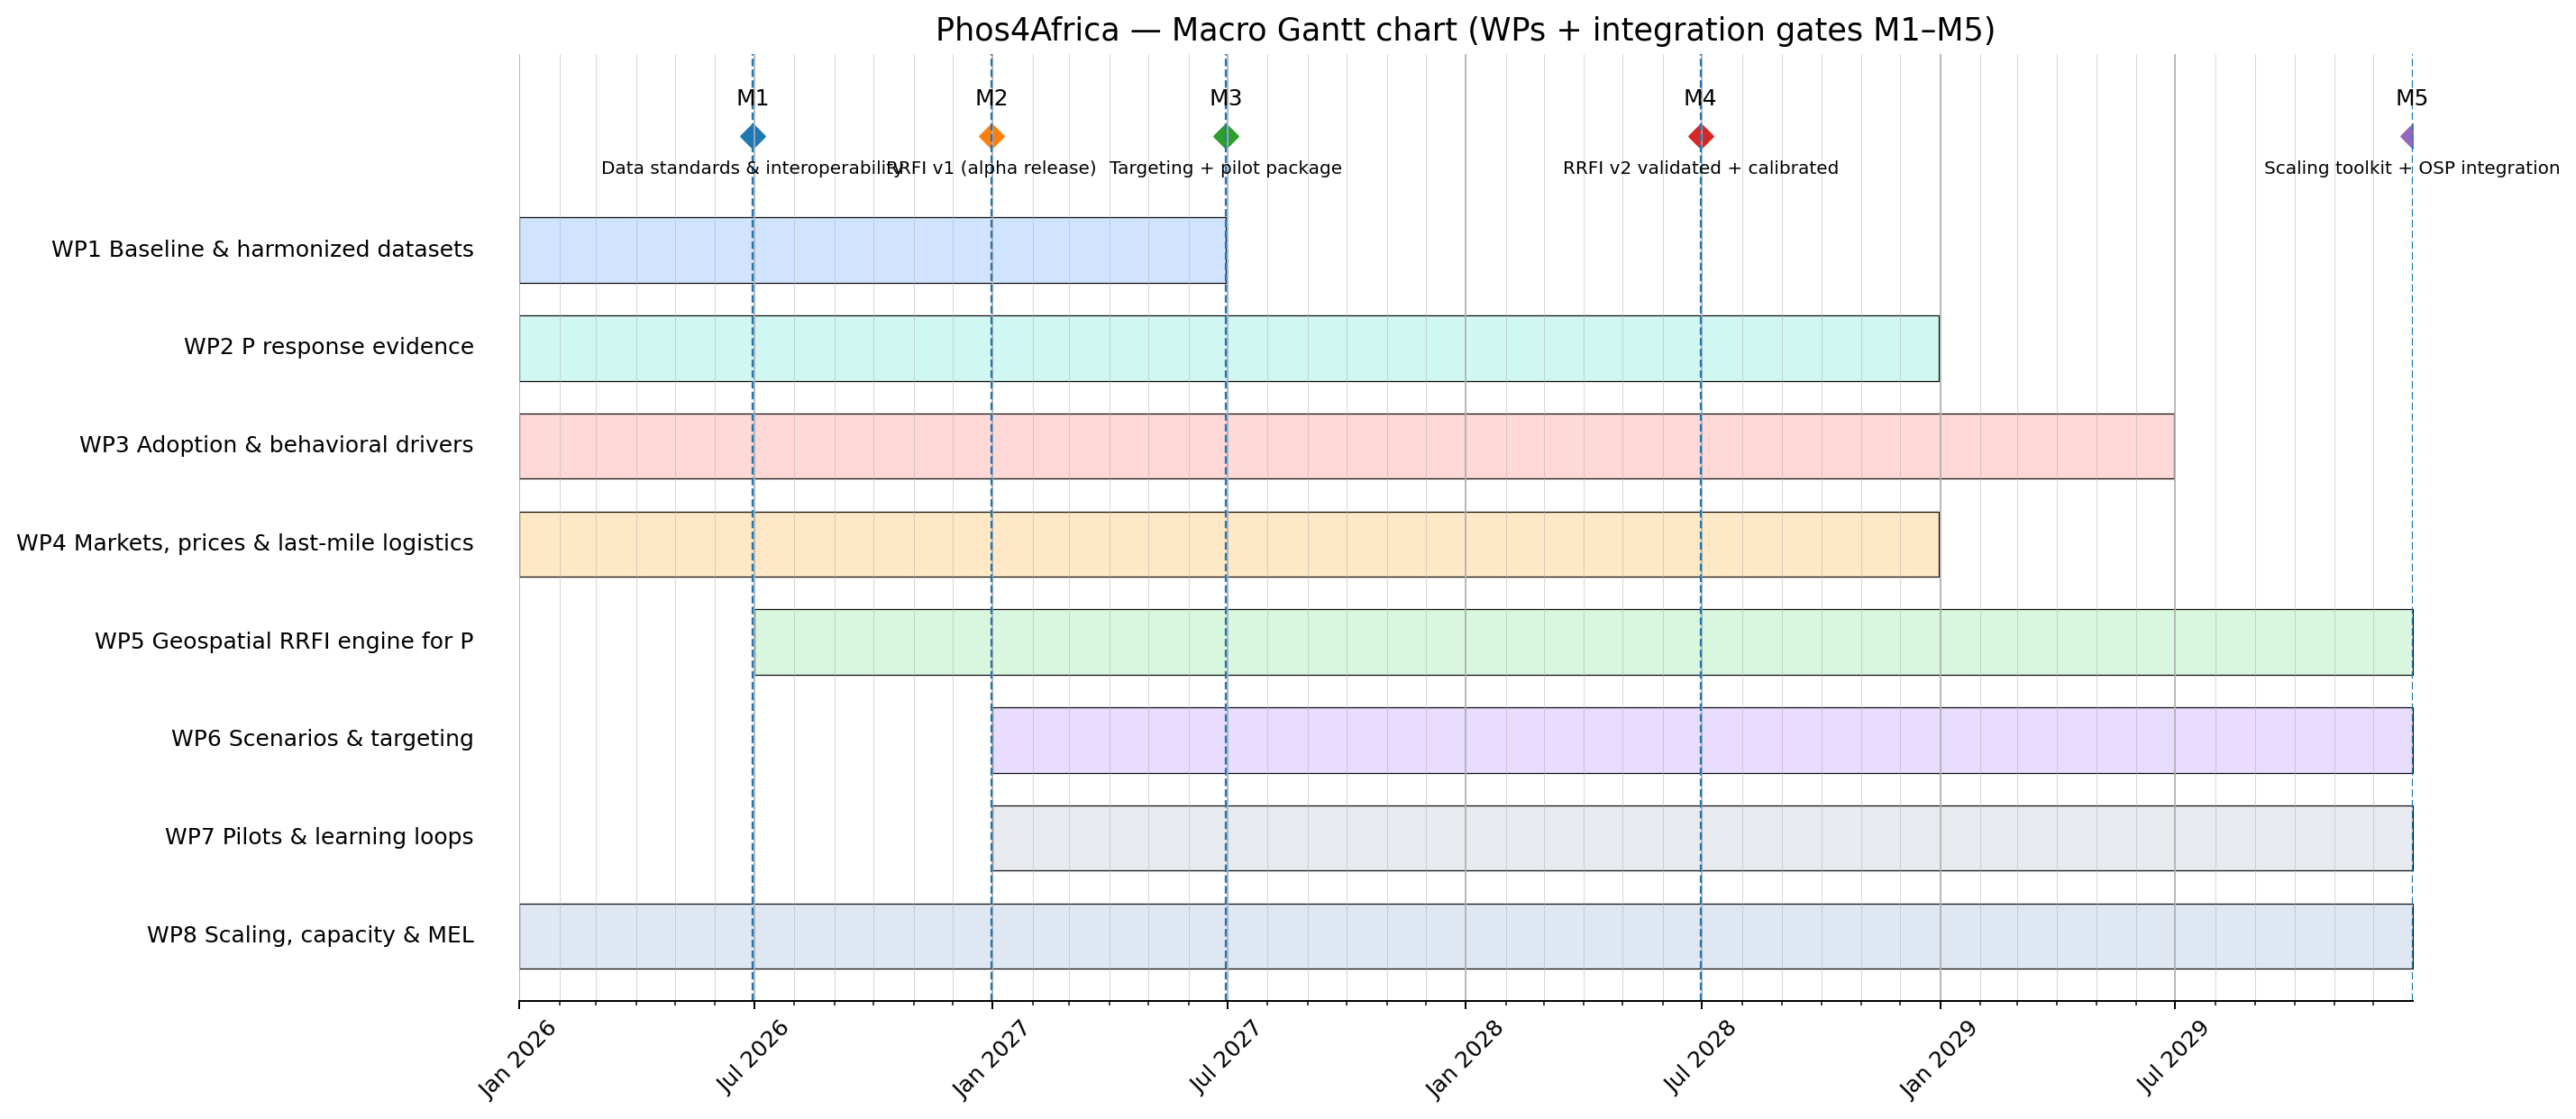

Saved: Phos4Africa_Macro_Gantt.png


In [ ]:
# --- Change only this block in your script to reverse order (WP1 at top → WP8 at bottom) ---

fig, ax = plt.subplots(figsize=(16, 7), dpi=180)

row_h = 8
row_gap = 4

# Draw WP bars in natural order with WP1 at the top
n = len(WPS)
for i, (label, s, e) in enumerate(WPS):
    # Compute y so first item (WP1) is highest
    y = (n - 1 - i) * (row_h + row_gap)

    ax.broken_barh([(num(s), span(s, e))], (y, row_h),
                   facecolors=WP_COLORS[i % len(WP_COLORS)],
                   edgecolor="black", linewidth=0.5, alpha=0.95)

    ax.text(num(START) - 35, y + row_h/2, label, ha="right", va="center", fontsize=10)

# Milestone row above the top WP
milestone_y = n * (row_h + row_gap) + 6

# Add gate markers, labels, and vertical lines
for code, dt, desc in GATES:
    x = num(dt)
    ax.axvline(x, linestyle="--", linewidth=0.9)
    ax.scatter([x], [milestone_y], marker="D", s=55)
    ax.text(x, milestone_y + 3.2, code, ha="center", va="bottom", fontsize=10)
    ax.text(x, milestone_y - 3.0, desc, ha="center", va="top", fontsize=8)

# Axis formatting
ax.set_xlim(num(START), num(END))
ax.set_ylim(-row_gap, milestone_y + 10)
ax.set_yticks([])

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
ax.grid(True, axis="x", which="major", linewidth=0.7)
ax.grid(True, axis="x", which="minor", linewidth=0.2)
ax.tick_params(axis="x", labelrotation=45)

ax.set_title("Phos4Africa — Macro Gantt chart (WPs + integration gates M1–M5)", fontsize=14)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
out = "Phos4Africa_Macro_Gantt.png"
plt.savefig(out, bbox_inches="tight")
plt.show()

print(f"Saved: {out}")


Saving STAR - Phos4Africa - Final.pdf to STAR - Phos4Africa - Final (1).pdf
Using: STAR - Phos4Africa - Final (1).pdf
Detected CV blocks: 15
First names: ['Bruno GERARD', 'Michel E. FENDER', 'Mohamed ARJI', 'Assistant Professor', 'Jun.-prof. Dr.', 'Frédéric Baudron', 'Associate Professor', 'Valetska Oksana']
Saved: cv_domain_raw_scores.csv, cv_domain_scores_0_5.csv


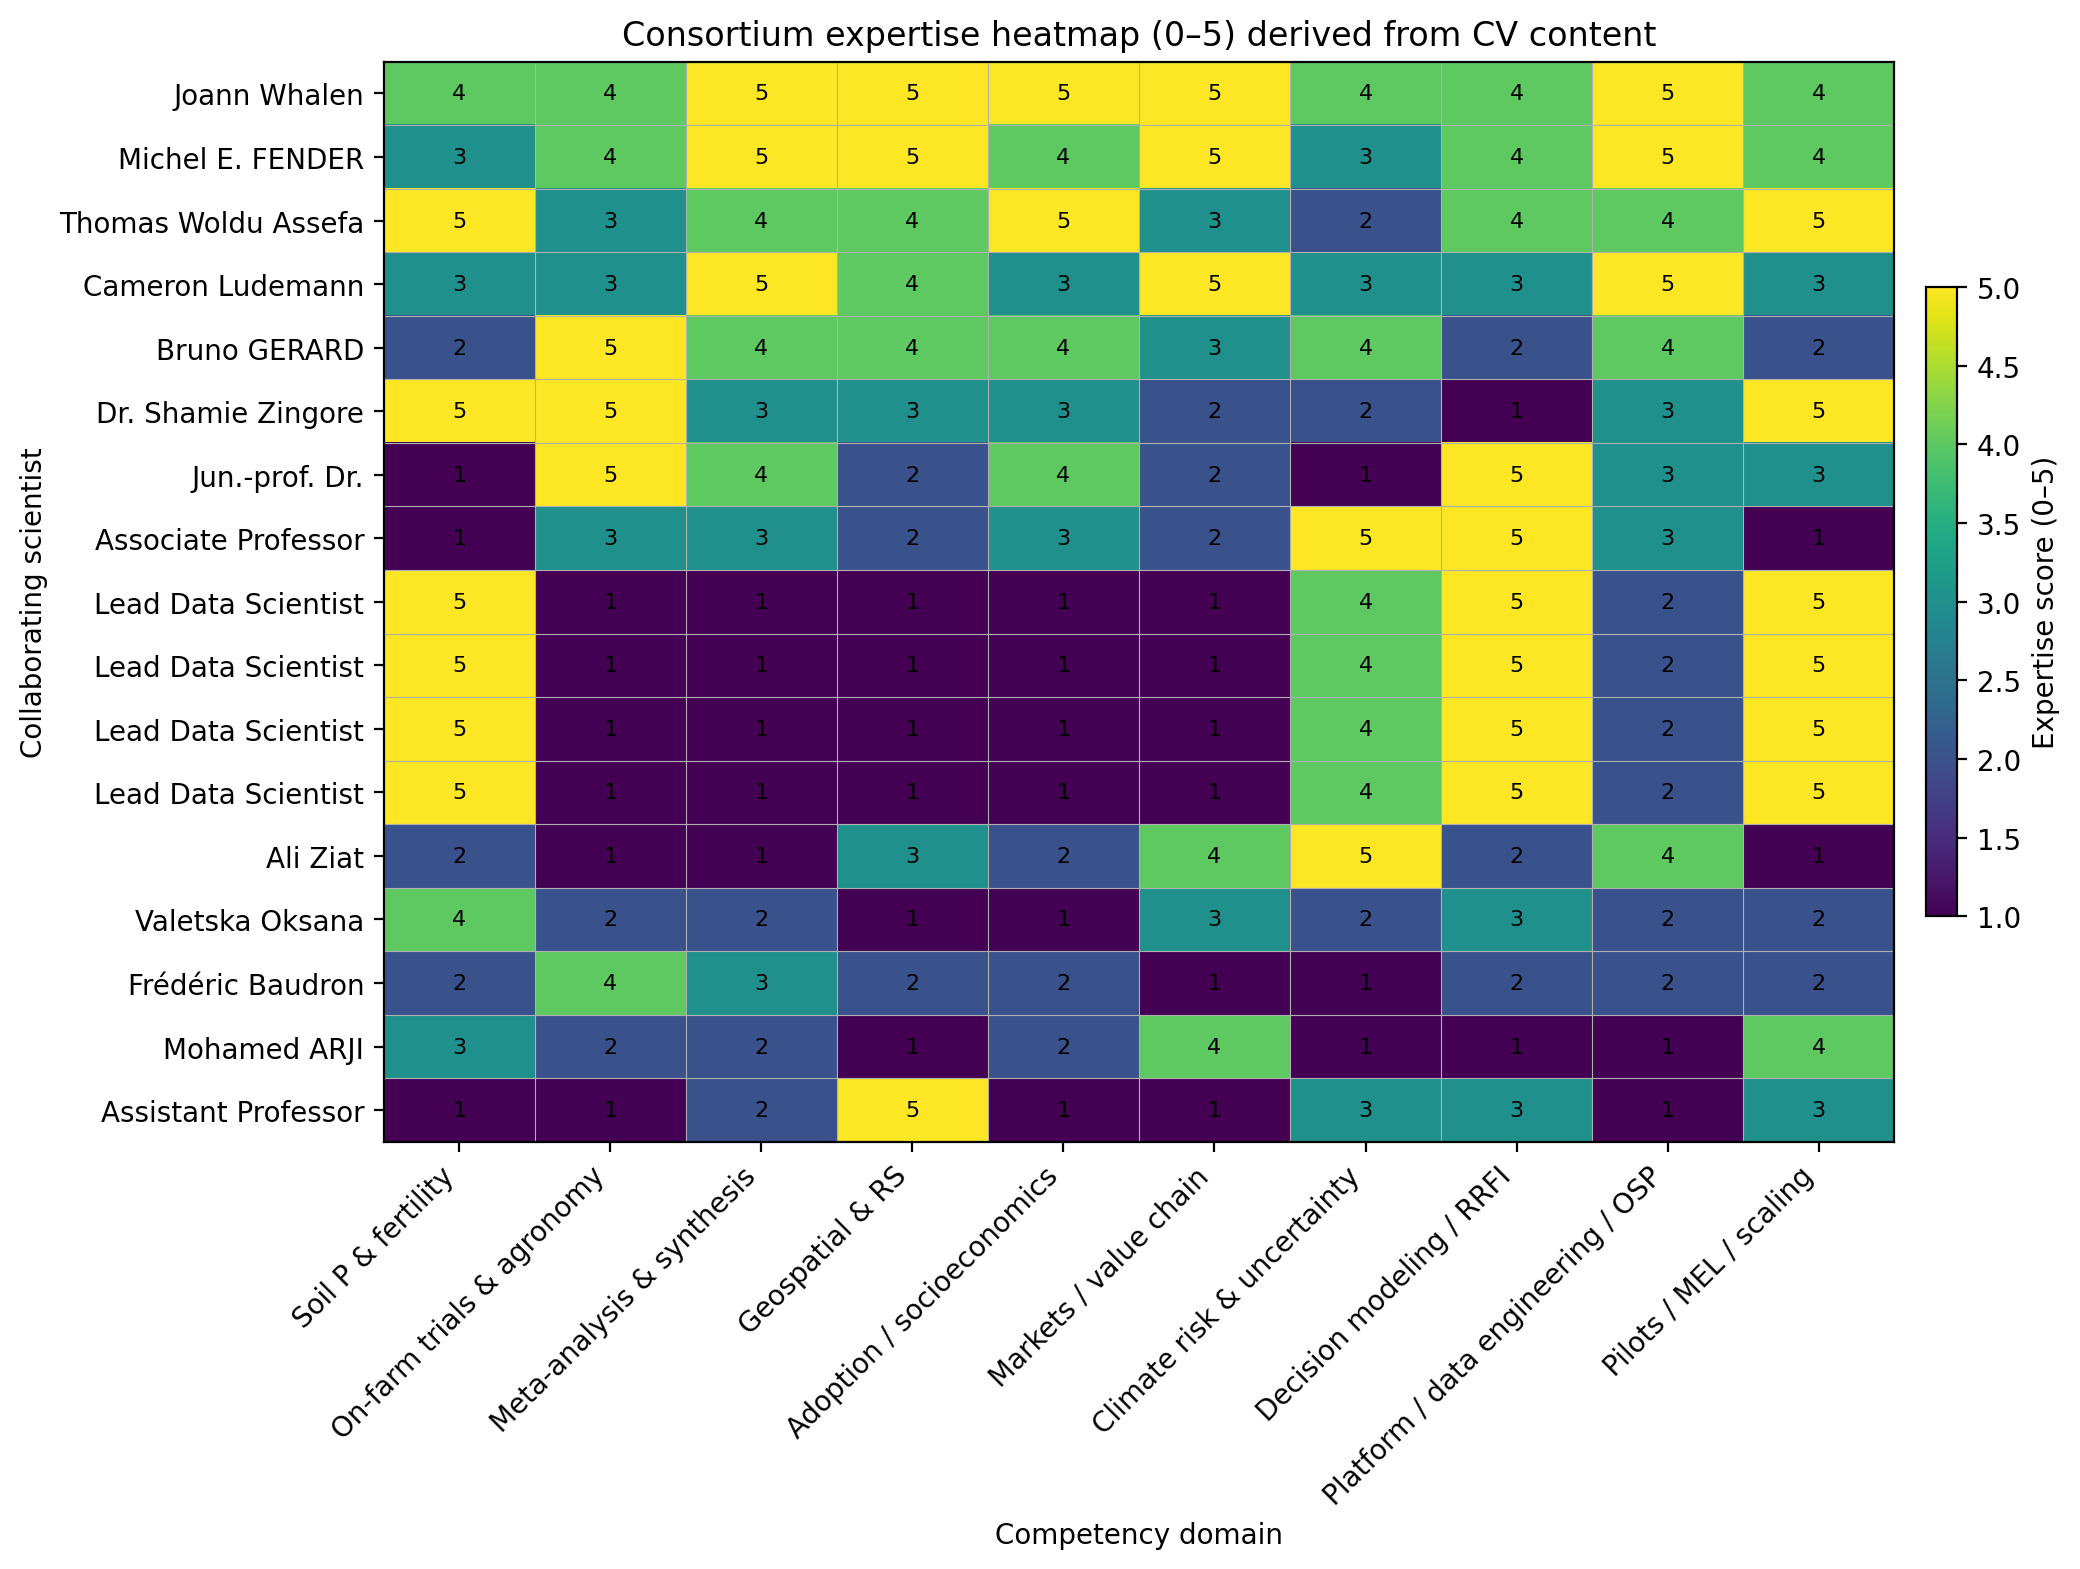

Saved: Phos4Africa_expertise_heatmap_0_5.png


In [ ]:
!pip -q install pdfplumber pandas numpy matplotlib regex

import pdfplumber
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import regex as re
from google.colab import files

# -----------------------------
# 1) Upload proposal PDF
# -----------------------------
uploaded = files.upload()
pdf_path = next(iter(uploaded.keys()))
print("Using:", pdf_path)

def extract_pdf_text(path):
    pages = []
    with pdfplumber.open(path) as pdf:
        for p in pdf.pages:
            pages.append(p.extract_text() or "")
    return "\n".join(pages)

full_text = extract_pdf_text(pdf_path)

# -----------------------------
# 2) Split CV blocks using repeated "Contact Information"
# (Works with many proposal CV annex formats)
# -----------------------------
HEADER_PAT = re.compile(r"(STAR calls|FULL PROPOSAL TEMPLATE|Annex\s+[A-Z])", re.IGNORECASE)

def is_name_like(line: str) -> bool:
    line = line.strip()
    if not (2 <= len(line.split()) <= 6):
        return False
    if not re.match(r"^[A-Za-zÀ-ÿ'’\-\.\s]+$", line):
        return False
    # avoid obvious non-names
    bad = {"and","or","for","with","through","from","in","on","to","the","a","an"}
    if any(t.lower() in bad for t in line.split()):
        return False
    # require Capitalized tokens (rough heuristic)
    caps = sum(1 for t in line.split() if re.match(r"^[A-ZÀ-Ý]", t) or t.isupper())
    return caps >= 2

def infer_name_before(pos: int, text: str, window_chars: int = 900) -> str:
    pre = text[max(0, pos - window_chars):pos]
    lines = [ln.strip() for ln in pre.splitlines() if ln.strip()]
    lines = [ln for ln in lines if not HEADER_PAT.search(ln)]

    # Try "Name: ..."
    for ln in reversed(lines[-40:]):
        m = re.search(r"\b(Full\s*Name|Name)\s*:\s*(.+)$", ln, flags=re.IGNORECASE)
        if m:
            return m.group(2).strip()

    # Else pick closest name-like line
    for ln in reversed(lines[-30:]):
        if is_name_like(ln):
            return ln

    return f"CV_{pos}"

contact_positions = [m.start() for m in re.finditer(r"Contact Information", full_text, flags=re.IGNORECASE)]
if len(contact_positions) < 2:
    raise RuntimeError("Could not find repeated 'Contact Information'. If CVs are scanned images, OCR may be needed.")

names = [infer_name_before(p, full_text) for p in contact_positions]

starts = []
for p, nm in zip(contact_positions, names):
    window = full_text[max(0, p-1500):p]
    local = window.rfind(nm)
    starts.append(max(0, p-1500) + local if local >= 0 else max(0, p-1000))

blocks = []
for i in range(len(starts)):
    s = starts[i]
    e = starts[i+1] if i+1 < len(starts) else len(full_text)
    blocks.append({"Name": names[i], "Text": full_text[s:e].strip()})

print("Detected CV blocks:", len(blocks))
print("First names:", [b["Name"] for b in blocks[:8]])

# -----------------------------
# 3) Competency domains (edit keywords if needed)
# -----------------------------
DOMAINS = {
    "Soil P & fertility": [
        r"\bphosph(or(us|ous)|ate|orus)\b", r"\bP\b", r"\bfertil(ity|izer|isation|ization)\b",
        r"\bplant nutrition\b", r"\bsoil test"
    ],
    "On-farm trials & agronomy": [
        r"\bfield trial", r"\bon[-\s]?farm\b", r"\bexperiment(al)? design\b", r"\bagronom(y|ic)\b",
        r"\byield\b", r"\bcrop management\b"
    ],
    "Meta-analysis & synthesis": [
        r"\bmeta[-\s]?analysis\b", r"\bsystematic review\b", r"\bevidence synthesis\b",
        r"\bprotocol\b", r"\bPRISMA\b"
    ],
    "Geospatial & RS": [
        r"\bGIS\b", r"\bgeospatial\b", r"\bremote sensing\b", r"\bEarth Engine\b", r"\bGEE\b",
        r"\bSentinel\b", r"\bMODIS\b", r"\braster\b"
    ],
    "Adoption / socioeconomics": [
        r"\badoption\b", r"\bbehavior(al)?\b", r"\bsocio[-\s]?economic(s)?\b", r"\beconometric(s)?\b",
        r"\bsurvey\b", r"\bconstraints?\b"
    ],
    "Markets / value chain": [
        r"\bvalue chain\b", r"\bsupply chain\b", r"\blast[-\s]?mile\b", r"\bmarket(s)?\b",
        r"\bprice(s)?\b", r"\blogistics\b"
    ],
    "Climate risk & uncertainty": [
        r"\bclimate\b", r"\bdrought\b", r"\brisk\b", r"\buncertaint(y|ies)\b",
        r"\bscenario(s)?\b"
    ],
    "Decision modeling / RRFI": [
        r"\bRRFI\b", r"\bdecision support\b", r"\boptimization\b",
        r"\btargeting\b", r"\bmodel(ling)?\b"
    ],
    "Platform / data engineering / OSP": [
        r"\bAPI\b", r"\binteroperab", r"\bdata model\b", r"\bmetadata\b", r"\bversioning\b",
        r"\bopen source\b", r"\bplatform\b", r"\bdata pipeline\b", r"\bETL\b"
    ],
    "Pilots / MEL / scaling": [
        r"\bpilot(s)?\b", r"\bMEL\b", r"\bmonitor(ing|)\b", r"\bevaluation\b",
        r"\bscal(ing|e)\b", r"\btraining\b", r"\bextension\b"
    ]
}

PUB_SIGNALS = [
    r"\bdoi\b", r"\bjournal\b", r"\bvol\.\b", r"\bpp\.\b", r"\bissue\b",
    r"\bproceedings\b", r"\bpublished\b", r"\baccepted\b", r"\bconference\b"
]
YEAR_RE = r"\b(19|20)\d{2}\b"

def score_text(text: str) -> dict:
    txt = text.lower()
    tokens = max(300, len(re.findall(r"\w+", txt)))  # normalize by length

    years = len(re.findall(YEAR_RE, txt))
    pubs  = sum(len(re.findall(p, txt)) for p in PUB_SIGNALS)
    pub_density = (years + pubs) / (tokens / 1000.0)  # per 1000 tokens

    scores = {"_tokens": tokens, "_pub_density": pub_density}

    for dom, pats in DOMAINS.items():
        hits = sum(len(re.findall(p, txt)) for p in pats)
        dom_density = hits / (tokens / 1000.0)

        # Raw score = keyword density + small publication boost
        scores[dom] = dom_density + 0.10 * pub_density

    return scores

rows = []
for b in blocks:
    s = score_text(b["Text"])
    s["Name"] = b["Name"]
    rows.append(s)

df_raw = pd.DataFrame(rows).set_index("Name")
domain_cols = list(DOMAINS.keys())

# -----------------------------
# 4) Convert raw scores -> expertise 0–5 (quantile bins)
# 0 = no signal at all
# 1–5 = increasing strength relative to consortium distribution
# -----------------------------
def to_0_5_quantiles(col: pd.Series) -> pd.Series:
    col = col.copy()
    out = pd.Series(0, index=col.index, dtype=int)

    # Non-zero values only for quantiles
    nz = col[col > 0]
    if len(nz) == 0:
        return out

    # Quantile cut points (5 bins)
    qs = nz.quantile([0.2, 0.4, 0.6, 0.8]).values

    for idx, v in col.items():
        if v <= 0:
            out.loc[idx] = 0
        elif v <= qs[0]:
            out.loc[idx] = 1
        elif v <= qs[1]:
            out.loc[idx] = 2
        elif v <= qs[2]:
            out.loc[idx] = 3
        elif v <= qs[3]:
            out.loc[idx] = 4
        else:
            out.loc[idx] = 5
    return out

df_scores_0_5 = df_raw[domain_cols].apply(to_0_5_quantiles, axis=0)

# Sort rows by overall expertise (optional)
df_scores_0_5 = df_scores_0_5.loc[df_scores_0_5.sum(axis=1).sort_values(ascending=False).index]

# Save outputs
df_raw.to_csv("cv_domain_raw_scores.csv")
df_scores_0_5.to_csv("cv_domain_scores_0_5.csv")
print("Saved: cv_domain_raw_scores.csv, cv_domain_scores_0_5.csv")

# -----------------------------
# 5) Plot heatmap (matplotlib only)
# -----------------------------
mat = df_scores_0_5.values
n_rows, n_cols = mat.shape

fig_w = max(10, 0.65*n_cols + 4)
fig_h = max(6, 0.35*n_rows + 2)

fig, ax = plt.subplots(figsize=(fig_w, fig_h), dpi=200)
im = ax.imshow(mat, aspect="auto")

ax.set_xticks(np.arange(n_cols))
ax.set_yticks(np.arange(n_rows))
ax.set_xticklabels(df_scores_0_5.columns, rotation=45, ha="right")
ax.set_yticklabels(df_scores_0_5.index)

ax.set_title("Consortium expertise heatmap (0–5) derived from CV content")
ax.set_xlabel("Competency domain")
ax.set_ylabel("Collaborating scientist")

# annotate values
for i in range(n_rows):
    for j in range(n_cols):
        ax.text(j, i, str(mat[i, j]), ha="center", va="center", fontsize=8)

# grid lines
ax.set_xticks(np.arange(-.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-.5, n_rows, 1), minor=True)
ax.grid(which="minor", linewidth=0.4)
ax.tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label("Expertise score (0–5)")

plt.tight_layout()
out_png = "Phos4Africa_expertise_heatmap_0_5.png"
plt.savefig(out_png, bbox_inches="tight")
plt.show()

print("Saved:", out_png)
